## Credit

Assignment developed by Sen Wang, Jing Wu, Vijay Upadhya, Haoxin Ma, Sergio Aguilera and Frank Dellaert.

# Assignment 4: 3D Pose Estimation, Objectron, and Stereo Matching

## Outline
The goal of this assignment is for you to experience working with state-of-the-art libraries and real-time processing of video. We will be working with [MediaPipe](https://ai.google.dev/edge/mediapipe/) which offers customizable Machine Learning solutions for live and streaming media. In this opportunity, we will use: [pose estimation](https://ai.google.dev/edge/mediapipe/solutions/vision/pose_landmarker) which estimates the pose of a person in real time; and [objectron](https://ai.google.dev/edge/mediapipe/solutions/vision/objectron) which is a 3D object detector from 2D images. With these two we will aim to identify an object that is being touched by a person.

Additionally, you will implement binocular stereo matching algorithms to compute disparity maps from rectified stereo pairs.

### Parts Overview
- **Part 1** (15 pts): 3D Bounding Box Detection (Objectron)
- **Part 2** (20 pts): Camera Calibration and Projection Matrix (DLT)
- **Part 3** (15 pts): Human Pose Estimation
- **Part 4** (15 pts): 2D to 3D Projection
- **Part 5** (15 pts): Intersection Detection
- **Part 6** (10 pts): Do It with Your Own Image
- **Part 7** (10 pts): Intersection Detection in a Video
- **Part 8** (52 pts): Binocular Stereo Matching + Depth Visualization

In [1]:
%load_ext autoreload
%autoreload 2

# Suppress TensorFlow and MediaPipe warnings
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['GLOG_minloglevel'] = '3'
import warnings
warnings.filterwarnings('ignore')
import logging
logging.getLogger('mediapipe').setLevel(logging.ERROR)
logging.getLogger('tensorflow').setLevel(logging.ERROR)
import absl.logging
absl.logging.set_verbosity(absl.logging.ERROR)

from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import cv2

from scripts.utils import *
from scripts.my_objectron import *
from scripts.pose_estimate import *
from scripts.intersection import *
from scripts.pnp import *

from tests.test_base import *
from tests.test_my_objectron import *
from tests.test_pose_estimate import *
from tests.test_intersection import *
from tests.test_pnp import *
from tests.test_utils import *

I0000 00:00:1777190556.284518   63333 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1777190562.222567   63333 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


---
## Part 1: 3D Bounding Box Detection on 2D Images (15 pts)

We're going to use a TFLite-based [Objectron](https://ai.google.dev/edge/mediapipe/solutions/vision/objectron) model based on this [paper](https://arxiv.org/pdf/2003.03522.pdf) to detect 3D bounding boxes of chairs in images.

<img src="https://mediapipe.dev/images/mobile/objectron_chair_android_gpu.gif" width="150"/>
<center>3D Objectron example.</center>

**Basically**, there are an encoder and a decoder for the detection part. Given an image, the encoder takes it as input, analyzes it, and gives some useful information in a certain form. Then the decoder takes these intermediate information as input, translates them into things we want (i.e., 8 vertices' 2D coordinates).

The encoder is trained as a neural network, whose weight file is provided and can be read by TensorFlow Lite (which is the `inference()` function in `scripts/my_objectron.py`). The decoder part is implemented as the `decode()` function. **You should read the paper and figure out what the intermediate information is to finish the coding work.**

### Detecting the 3D bounding boxes from the sample image

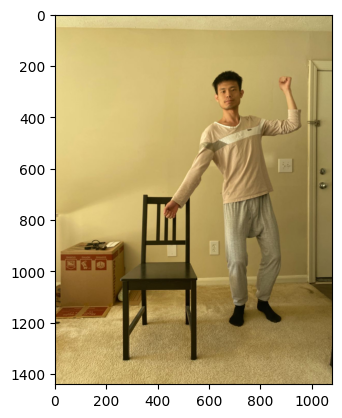

In [2]:
test_img = 'data/10.jpg'
img = cv2.imread(test_img)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img)
plt.show()

**TODO 1 (10 pts)**: Implement `detect_3d_box()` in `scripts/my_objectron.py`.

You need to:
1. Load the TFLite model using `tf.lite.Interpreter` and allocate tensors
2. Prepare the input image data and set it on the interpreter
3. Run inference (`invoke()`)
4. Extract the two output tensors (heatmap and displacement fields) and reshape them

The preprocessed image is already provided as `image` (a float32 CHW array). The model expects NHWC format. After inference, the outputs need to be reshaped so that `hm` has shape `[1, 1, 40, 30]` and `displacements` has shape `[1, 16, 40, 30]`. These are then passed to `decode()`.

This is an open-ended task — you are encouraged to consult the [Objectron API documentation](https://mediapipe.readthedocs.io/en/latest/solutions/objectron.html) and the [Objectron paper](https://arxiv.org/pdf/2003.03522.pdf).

INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


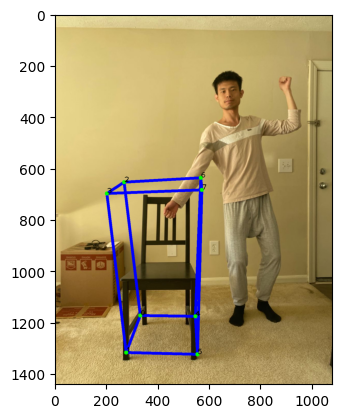

[(np.float64(0.30718899667263033), np.float64(0.8147120207548142)), (np.float64(0.2557764291763306), np.float64(0.9146355122327805)), (np.float64(0.24906049072742464), np.float64(0.45441165864467625)), (np.float64(0.18638592362403872), np.float64(0.4848366260528565)), (np.float64(0.5049543023109436), np.float64(0.8171480923891068)), (np.float64(0.5124379932880402), np.float64(0.9201360523700715)), (np.float64(0.5240779161453247), np.float64(0.4428676992654801)), (np.float64(0.5281747221946717), np.float64(0.47536436021327977))]


In [3]:
bounding_boxes_chair_2d, annotated_img = detect_3d_box(test_img)
plt.imshow(annotated_img)
plt.show()
print(bounding_boxes_chair_2d)

In [4]:
print("Testing your objectron detection: ", verify(test_my_objectron))

Testing your objectron detection:  "Correct"


### Objectron Written Questions (5 pts)

Answer the following questions in your PDF report:

1. **(2 pts)** What are the two intermediate representations (outputs) produced by the Objectron encoder network, and what does each one represent? How are they used to localize the 3D bounding box?

2. **(2 pts)** Describe how the `decode()` function converts the heatmap peak location and displacement fields into the 8 bounding box vertex coordinates. What role does the peak location play vs. the displacement values?

3. **(1 pt)** The Objectron model takes an input image of a fixed resolution (480×640). What happens if you feed it an image of a different resolution? How does the code handle this?

---
## Part 2: Estimation of World Coordinates of the Camera (20 pts)

### 2.1 Establish the World Coordinate Frame

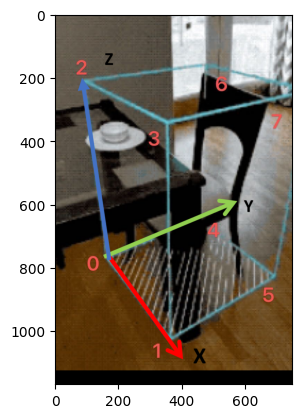

In [5]:
img_index = cv2.imread('data/world_frame.png')
img_index = cv2.cvtColor(img_index, cv2.COLOR_BGR2RGB)
plt.imshow(img_index)
plt.show()

We want to estimate the intrinsic camera matrix, but this time we will provide an initial estimation for a cube, giving 8 vertices in 3D coordinates. As shown in the image above, we have 8 vertices and we can define the world coordinate using these vertices. We will define the origin of the world at vertex 0, the `x-axis` by the line connecting vertices 0 and 1, the `y-axis` by vertices 0 and 4, and the `z-axis` by vertices 0 and 2. Then, we need to give an estimation of the dimensions of the chair to calculate the location of the coordinates in the world frame.

**TODO 2a (10 pts)**: Implement `get_world_vertices()` in `scripts/utils.py`.

In [6]:
# Measure the size of the chair and set dimensions here.
# For example, the example chair's size is 0.4m x 0.4m x 1.0m
size_x = 0.4
size_y = 0.4
size_z = 1.0
vertices_world = get_world_vertices(size_x, size_y, size_z)
print(vertices_world)

initial_box_points_3d = vertices_world
print("Testing your get_world_vertices: ", verify(test_get_world_vertices))

[[0.  0.  0. ]
 [0.4 0.  0. ]
 [0.  0.  1. ]
 [0.4 0.  1. ]
 [0.  0.4 0. ]
 [0.4 0.4 0. ]
 [0.  0.4 1. ]
 [0.4 0.4 1. ]]
Testing your get_world_vertices:  "Correct"


### 2.2 Estimate Intrinsic Matrix of Your Camera

For the camera intrinsic matrix, we use OpenCV to calibrate.

**For the first run**, you can use our provided example checkerboard images as-is — just run the cell below with the default `path2 = 'data/cali2/example2/'` to verify your pipeline works end-to-end.

**For Part 6 (your own images)**, you **must** re-calibrate with your own camera. This is because the intrinsic matrix is camera-specific. To do so:
1. Print or display the checkerboard from `data/Checkerboard-A4-35mm-7x4.pdf`
2. Take **>10 pictures** of it from **different angles** with **your** camera (the same camera you will use for the chair interaction photos)
3. Save your calibration images to a folder (e.g., `data/cali2/my_camera/`)
4. Update the `path2` variable below to point to your folder
5. Re-run this cell to get the intrinsic matrix for your camera

Important tips:
- Look at the example calibration pictures in `data/cali2/example2/` first
- Cover different views by taking pictures from different angles, avoid very similar pictures
- Use pictures of the **same resolution** for all tasks (calibration, chair, pose)
- **Fix the focal length** on your phone camera (avoid auto-adjustment)

In [7]:
from scripts.calibration import calibrate

path2 = 'data/cali2/example2/'  # update the path to where you save your pictures
m = 5  # vertice number in x direction
n = 7  # vertice number in y direction

K = calibrate(path2)

### 2.3 Estimate Camera Projection Matrix (DLT)

Given the 8 vertices of the bounding box in both 2D image coordinates and 3D world coordinates, we can estimate the 3x4 camera projection matrix $M$ using the **Direct Linear Transform (DLT)**.

The DLT sets up a homogeneous linear system from the projection equations:

$$s \begin{bmatrix} u \\ v \\ 1 \end{bmatrix} = M \begin{bmatrix} X \\ Y \\ Z \\ 1 \end{bmatrix}$$

Each 2D-3D correspondence $(u,v) \leftrightarrow (X,Y,Z)$ gives two linear equations in the 12 unknowns of $M$. Stacking all correspondences gives a $2N \times 12$ system $A\mathbf{m} = 0$, solved via SVD.

You will also implement helper functions:
- `camera_center(M)`: extract the camera center $C = -A^{-1}\mathbf{m}_4$ from $M = [A \mid \mathbf{m}_4]$
- `project(M, points3d)`: forward-project 3D points to 2D
- `reprojection_error(M, points3d, points2d)`: per-point L2 reprojection error


**TODO 2b (10 pts)**: Implement the following functions in `scripts/pnp.py`:

1. `camera_center(M)` — extract the camera center from the projection matrix
2. `project(M, points3d)` — forward-project 3D world points to 2D image coordinates
3. `reprojection_error(M, points3d, points2d)` — compute per-point L2 reprojection error
4. `estimate_camera_matrix(points2d, points3d)` — estimate $M$ via DLT

**Hint for DLT**: Each correspondence $(u,v) \leftrightarrow (X,Y,Z)$ contributes two rows to the system matrix $A$:

$$\begin{bmatrix} X & Y & Z & 1 & 0 & 0 & 0 & 0 & -uX & -uY & -uZ & -u \\
0 & 0 & 0 & 0 & X & Y & Z & 1 & -vX & -vY & -vZ & -v \end{bmatrix}$$

The solution $\mathbf{m}$ is the last column of $V$ from the SVD $A = U \Sigma V^T$, reshaped into a $3 \times 4$ matrix.

**Important**: DLT determines $M$ only up to scale. After solving, normalize $M$ so that $\|\mathbf{m}_3\| = 1$ where $\mathbf{m}_3$ is the first three elements of the third row. Also ensure $M_{3,4} > 0$ (so that points in front of the camera have positive depth). This normalization is critical for the 2D-to-3D back-projection in Part 4.


In [8]:
from scripts.pnp import estimate_camera_matrix, camera_center, project, reprojection_error, plot_box_and_camera

bounding_boxes = bounding_boxes_chair_2d
height = annotated_img.shape[0]
width = annotated_img.shape[1]

box_points_2d = np.array(bounding_boxes)
box_points_2d[:, 0] *= width
box_points_2d[:, 1] *= height

# Step 1: Estimate M via DLT
M_dlt, residual = estimate_camera_matrix(box_points_2d, initial_box_points_3d)
print('DLT Projection matrix M:')
print(M_dlt)
print(f'DLT residual: {residual:.4f}')
dlt_mean_err = np.mean(reprojection_error(M_dlt, initial_box_points_3d, box_points_2d))
print(f'DLT mean reprojection error: {dlt_mean_err:.2f} px')

# Sanity check: a correct DLT implementation should achieve < 10 px mean error
if dlt_mean_err < 10:
    print("\x1b[32mDLT reprojection error looks correct!\x1b[0m")
else:
    print("\x1b[31mWarning: DLT mean reprojection error > 10 px — check your implementation.\x1b[0m")

# Step 2: Refine using solvePnP with DLT as initial guess.
# DLT is a linear method — it doesn't enforce that M decomposes into K[R|t]
# where R is a proper rotation. We use cv2.solvePnP with the DLT-derived
# initial R,t to get a nonlinearly refined solution.
#
# NOTE: The refined reprojection error may be *higher* than the DLT error.
# This is expected — DLT minimizes algebraic error and can overfit noisy 2D
# detections, while solvePnP enforces physical constraints (known K, proper
# rotation matrix). The PnP result has correct metric scale in M = K@[R|t],
# which is essential for projection_2d_to_3d() where depth is in meters.
K_inv = np.linalg.inv(K)
R_approx = K_inv @ M_dlt[:, :3]
U_r, _, Vt_r = np.linalg.svd(R_approx)
R_init = U_r @ Vt_r
if np.linalg.det(R_init) < 0:
    R_init = -R_init
rvec_init, _ = cv2.Rodrigues(R_init)
tvec_init = K_inv @ M_dlt[:, 3:]

_, rvec, tvec = cv2.solvePnP(
    initial_box_points_3d.astype('float32'),
    box_points_2d.astype('float32'),
    K, None,
    rvec=rvec_init.astype('float32'),
    tvec=tvec_init.astype('float32'),
    useExtrinsicGuess=True
)
wRc_T, _ = cv2.Rodrigues(rvec)
M = K @ np.hstack([wRc_T, tvec])

print(f'\nRefined mean reprojection error: {np.mean(reprojection_error(M, initial_box_points_3d, box_points_2d)):.2f} px')


DLT Projection matrix M:
[[-4.70468651e+02  1.03541028e+03 -2.32709627e+02  6.52034075e+02]
 [-4.35554556e+02 -1.38122471e+02 -1.34294033e+03  2.34268566e+03]
 [-8.74936486e-01 -1.30353823e-01 -4.66362548e-01  1.99656550e+00]]
DLT residual: 143.0307
DLT mean reprojection error: 4.00 px
DLT reprojection error looks correct!

Refined mean reprojection error: 28.04 px


Visualize the world coordinate of the box object and camera pose:


The camera center is at: 
 [1.88611754 0.44204089 1.41096545]


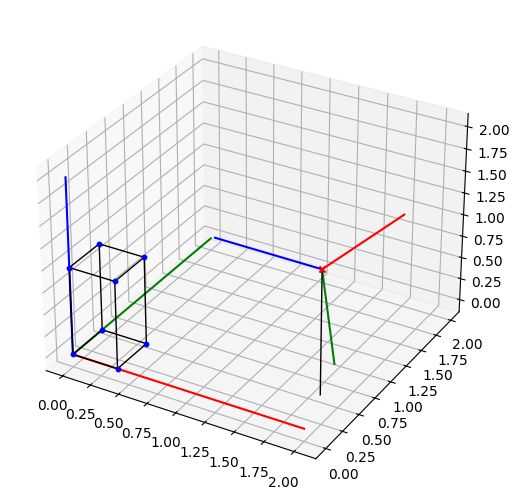

In [9]:
cc = camera_center(M)
R = wRc_T.T  # world-to-camera rotation transposed = camera axes in world frame

plot_box_and_camera(initial_box_points_3d, cc, R)


In [10]:
from tests.test_pnp import test_estimate_camera_matrix
print('Testing your DLT functions:', verify(test_estimate_camera_matrix))


Testing your DLT functions: "Correct"


---
## Part 3: Human Pose Estimation (15 pts)

In this part, you will use [MediaPipe](https://ai.google.dev/edge/mediapipe/solutions/vision/pose_landmarker) to do pose estimation from images. Human Pose Estimation is defined as the problem of localization of human joints (keypoints - elbows, wrists, etc.) in images or videos. It has applications in action recognition, AR/VR, animation, gaming, etc.

You will use the **MediaPipe Tasks API** (`mp.tasks.vision.PoseLandmarker`). See the [Python guide](https://ai.google.dev/edge/mediapipe/solutions/vision/pose_landmarker/python) for details.

<img src="https://qaihub-public-assets.s3.us-west-2.amazonaws.com/qai-hub-models/models/mediapipe_pose/web-assets/banner.png" width="500"/>
<center>Pose detection example.</center>

**TODO 3 (10 pts)**: Implement `hand_pose_img()` in `scripts/pose_estimate.py`.

You need to:
1. Create a `PoseLandmarkerOptions` with the model from `_get_model_path()`
2. Create a `PoseLandmarker` and call `.detect()` on the image
3. Store the detection result in a variable called `result`
4. Convert the normalized landmark coordinates (0-1) to pixel coordinates by multiplying by image width/height, and store in a numpy array called `landmark1` of shape `(n, 2)`

See the [Python guide](https://ai.google.dev/edge/mediapipe/solutions/vision/pose_landmarker/python) for API details.

INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1777190568.804443   63465 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1777190569.002180   63465 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1777190569.124848   63464 landmark_projection_calculator.cc:78] Using NORM_RECT without IMAGE_DIMENSIONS is only supported for the square ROI. Provide IMAGE_DIMENSIONS or use PROJECTION_MATRIX.


Detected landmark numbers:  33


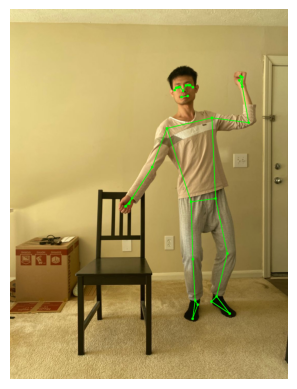

In [11]:
test_img = 'data/10.jpg'

land_mark, annotated_image = hand_pose_img(test_img)
print('Detected landmark numbers: ', len(land_mark))
imshow1(annotated_image)

In [12]:
# Although you may say this is actually the right hand physically,
# we call it left hand to be consistent with mediapipe's naming convention.
left_thumb = land_mark[22]
print(left_thumb)

[463.7745595  757.56903648]


In [13]:
print("Testing your pose estimation: ", verify(test_pose_estimate))

W0000 00:00:1777190569.642113   63475 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1777190569.737750   63474 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


Testing your pose estimation:  "Correct"


### Pose Estimation Written Questions (5 pts)

Answer the following questions in your PDF report:

1. **(2 pts)** How many landmarks does MediaPipe's PoseLandmarker detect per person? Name at least 4 specific body parts that correspond to landmark indices, and explain why having this many landmarks (vs. fewer) is useful for applications like AR or action recognition.

2. **(2 pts)** The pose landmarks returned by MediaPipe are in normalized coordinates (values between 0 and 1). Why does MediaPipe return them this way instead of in pixel coordinates? What is the advantage of this representation?

3. **(1 pt)** In this assignment, we use landmark index 22 for hand-object intersection detection. What body part does this index correspond to? Why might this be a better choice than using the wrist (index 16) for detecting whether a hand is touching an object?

---
## Part 4: Projection of 2D Pose Estimation to 3D World Coordinates (15 pts)

In this section, you're going to detect the 3D coordinates of the human pose in the world coordinate frame (the chair-center frame). The projection matrix from Part 2 can be reused because we're using the same camera at the same position.

The projection function is the inverse of what you did in previous assignments: we back-project from 2D to 3D rather than project from 3D to 2D.

$$z\begin{bmatrix} x_p \\ y_p \\ 1 \end{bmatrix} = P \begin{bmatrix} x_w \\ y_w \\ z_w \\ 1 \end{bmatrix}$$

Generally, we cannot fully recover 3D coordinates from 2D feature points because depth information is lost. You're asked to provide the depth $z$ (physical distance between the subject and camera in meters).

In this project, you work with three coordinate frames:
1. **World frame** (chair frame, 3D)
2. **Camera-centric frame** (3D)
3. **Image frame** (2D)

**TODO 4 (15 pts)**: Implement `projection_2d_to_3d()` in `scripts/utils.py`.

In [14]:
# M is the refined projection matrix
print('Projection matrix M:')
print(M)


Projection matrix M:
[[-5.49164146e+02  1.15967575e+03 -8.81120599e+01  6.47487099e+02]
 [-3.89743698e+02  5.81521447e+01 -1.12059011e+03  2.29051073e+03]
 [-9.81727302e-01  1.44396514e-01 -1.23939887e-01  1.96269882e+00]]


In [15]:
print(land_mark.shape)

depth = 1.91

pose3d_landmark = projection_2d_to_3d(M, depth, land_mark)

left_hand = pose3d_landmark[22]
print('Your 3D pose landmark of the left hand is ', left_hand)

print('Testing your 3d human pose estimate: ', verify(test_projection_2d_to_3d))


(33, 2)
Your 3D pose landmark of the left hand is  [-0.00480547  0.26158638  0.76802265]
Testing your 3d human pose estimate:  "Correct"


In [16]:
# Test if you can project the origin back correctly
M.dot(np.array([0,0,0,1]).T) / M.dot(np.array([0,0,0,1]).T)[2]


array([3.29896311e+02, 1.16702100e+03, 1.00000000e+00])

---
## Part 5: Intersection between Pose and Objectron (15 pts)

After detecting both the 3D coordinates of human pose and the 3D coordinates of the 8 vertices of the chair, we can now detect whether the hand is inside the bounding box. If so, we change the color of the bounding box. This is useful for collision checking and obstacle avoidance.

**TODO 5 (15 pts)**: Implement `check_hand_inside_bounding_box()` in `scripts/intersection.py`.

In [17]:
print('Test for intersection checking:', verify(test_check_hand_inside_bounding_box))

Test for intersection checking: "Correct"


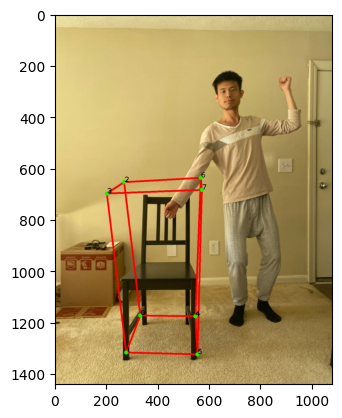

In [18]:
annotated_img = draw_box_intersection(img, left_hand, vertices_world, bounding_boxes_chair_2d)

plt.imshow(annotated_img)
plt.show()

---
## Part 6: Do It with Your Own Image! (10 pts)

This assignment is designed to make you interact with your own images and accumulate real-world computer vision experience. You're required to take your own pictures, do the calibration, and run detection and estimation with your code. Include the results in your report.

**You will receive zero credit if you only demonstrate results on the provided sample images.** You must capture your own images with a person interacting with a chair.

Tips:
- Take pictures for both **before** (hand is far from chair) and **after** interaction
- Use the same camera and focal length for calibration and interaction pictures
- Use pictures of the same resolution for all tasks
- MediaPipe and Objectron do not work in all situations: try different subjects, poses, lighting, and backgrounds
- You may slightly adjust real-world parameters (chair size, depth) for better results


---
## Part 7: Intersection Detection in a Video (10 pts)

Now that you have a working pipeline for a single image, extend it to process a video and handle more than one object.

- **Video processing**: Write code that reads a video file and applies the pipeline frame by frame. Your function should **sample `num_frames` evenly-spaced frames** from the video, run the full pipeline on each, and **return a list of annotated RGB images**.
- **Interacting with multiple objects**: Record a video with at least one chair and a person interacting with it. The bounding box should change colors while the hand is inside the chair.

**You will receive zero credit if you only demonstrate results on the provided sample video.** You must record your own video.

**Note**: Since DLT estimates the projection matrix $M$ directly from 2D-3D correspondences (detected per frame), you do **not** need a separate camera calibration for the video. You only need to set the correct `depth` and chair dimensions for your setup.

**Hint**: If you use camera calibration in your video pipeline and your video resolution differs from the calibration image resolution (e.g., calibration was done at 1080×1440 but video is 960×544), you must scale the intrinsic matrix K accordingly. Check for this mismatch and adjust `fx`, `fy`, `cx`, `cy`.

**TODO 7 (10 pts)**: Implement `process_video()` in `scripts/video.py`.

In the report, answer all questions about this section to receive full credit.


In [19]:
from scripts.video import process_video

# IMPORTANT: Update these parameters for YOUR setup:
#   - video_path: path to your recorded video
#   - depth: distance from camera to person in meters
#   - calib_path: path to calibration images
#   - size_x, size_y, size_z: chair dimensions in meters
video_path = 'data/cali2/video.mp4'
frames = process_video(video_path, num_frames=20, depth=1.91,
                       calib_path='data/cali2/example2/',
                       size_x=0.4, size_y=0.4, size_z=1.0)

# Display sampled frames as a grid
if frames:
    n = len(frames)
    cols = 5
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(20, 4 * rows))
    axes = axes.flatten()
    for i, frame in enumerate(frames):
        axes[i].imshow(frame)
        axes[i].set_title(f'Frame {i+1}')
        axes[i].axis('off')
    for i in range(n, len(axes)):
        axes[i].axis('off')
    plt.tight_layout()
    plt.show()


---
## Part 8: Binocular Stereo Matching (52 pts)

In this part, you will implement window-based stereo matching to estimate disparity and depth from rectified stereo pairs. You will compare SSD, SAD, and NCC matching functions, analyze parameter choices, and convert disparity to depth for 3D visualization.

### 8.1 Introduction to Stereo Vision

A rectified stereo pair is aligned so that corresponding points lie on the same image row (epipolar lines are horizontal). This lets us search for matches along a single scanline. The horizontal offset between corresponding pixels is the **disparity**.

For a rectified pair, the depth $Z$ is related to disparity $d$ by:

$$Z = \frac{B \cdot f}{d}$$

where $B$ is the baseline between cameras and $f$ is the focal length (in pixels).

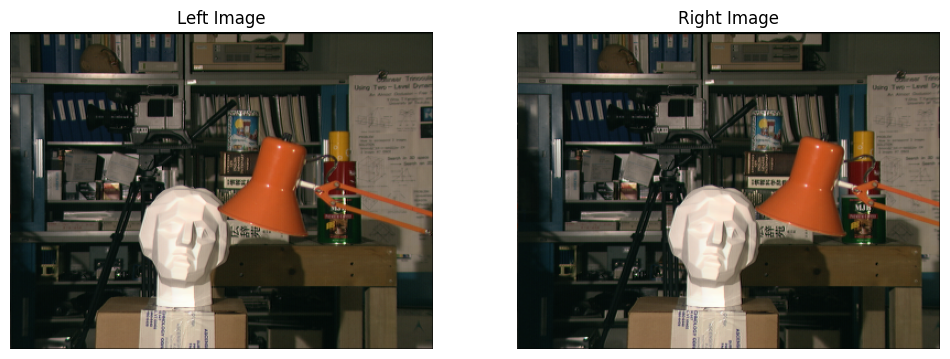

In [20]:
# Visualize a rectified stereo pair (Tsukuba)
# Official Middlebury 2001 dataset: https://vision.middlebury.edu/stereo/data/scenes2001/
# scene1.row3.col3.ppm is the left (reference) image, scene1.row3.col1.ppm is the right image.
# Ground truth disparity is for the left image, scaled by a factor of 8.
left_path = os.path.join('data', 'stereo_pairs', 'scene1.row3.col3.ppm')
right_path = os.path.join('data', 'stereo_pairs', 'scene1.row3.col1.ppm')

left_color = cv2.cvtColor(cv2.imread(left_path), cv2.COLOR_BGR2RGB)
right_color = cv2.cvtColor(cv2.imread(right_path), cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(left_color)
plt.title('Left Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(right_color)
plt.title('Right Image')
plt.axis('off')
plt.show()


### 8.2 Window-Based Stereo Matching

We compute a disparity map by comparing small windows between the left (reference) image and the right image:

1. Choose a window size (odd number) and maximum disparity.
2. For each pixel, extract a window centered at that pixel in the left image.
3. Slide the window along the corresponding scanline in the right image within the disparity range.
4. Compute a matching cost (SSD, SAD, or NCC) for each candidate.
5. Select the disparity with the best score (minimum for SSD/SAD, maximum for NCC).

In [21]:
from scripts.stereo import *

left_gray, right_gray, left_color = load_stereo_pair(left_path, right_path)
right_color = cv2.cvtColor(cv2.imread(right_path), cv2.COLOR_BGR2RGB)


### 8.3 Sum of Squared Differences (SSD)

**TODO 8a (15 pts)**: Implement `compute_disparity_ssd()` in `scripts/stereo.py`.

In [22]:
window_size = 7
max_disparity = 64

disparity_ssd = compute_disparity_ssd(left_gray, right_gray, window_size, max_disparity)
visualize_disparity(disparity_ssd, title=f'SSD Disparity (ws={window_size})')


NotImplementedError: `compute_disparity_ssd` function in stereo.py needs to be implemented

### 8.4 Sum of Absolute Differences (SAD)

**TODO 8b (10 pts)**: Implement `compute_disparity_sad()` in `scripts/stereo.py`.

In [ ]:
disparity_sad = compute_disparity_sad(left_gray, right_gray, window_size, max_disparity)
visualize_disparity(disparity_sad, title=f'SAD Disparity (ws={window_size})')

### 8.5 Normalized Cross-Correlation (NCC)

**TODO 8c (15 pts)**: Implement `compute_disparity_ncc()` in `scripts/stereo.py`.

In [ ]:
disparity_ncc = compute_disparity_ncc(left_gray, right_gray, window_size, max_disparity)

compare_disparity_maps(
    [disparity_ssd, disparity_sad, disparity_ncc],
    ['SSD', 'SAD', 'NCC']
)

### Ground Truth Comparison

We provide a ground truth disparity map for the Tsukuba pair (`data/stereo_pairs/truedisp.row3.col3.pgm`). Use this to visually and quantitatively evaluate the quality of your disparity maps.

### 8.6 Parameter Analysis (Report Questions)

In your report, answer the following:
- **Window size analysis**: show disparity maps for window sizes 3, 7, 11, 21 and discuss the tradeoffs.
- **Disparity range selection**: how does changing `max_disparity` affect quality and runtime?
- **Matching function comparison**: compare SSD, SAD, and NCC in terms of accuracy and speed.
- **Algorithm shortcomings and improvements**: where does window-based matching fail and why?
- **Running time analysis**: quantify the cost of different parameters and methods.

In [ ]:
# Load ground truth disparity map
gt_disp_path = os.path.join('data', 'stereo_pairs', 'truedisp.row3.col3.pgm')
gt_disparity = cv2.imread(gt_disp_path, cv2.IMREAD_GRAYSCALE).astype(np.float32)

# Divide by 8 to get actual disparity values (Middlebury 2001 convention)
gt_disparity /= 8.0

# Compare your disparity maps against ground truth
compare_disparity_maps(
    [gt_disparity, disparity_ssd, disparity_sad, disparity_ncc],
    ['Ground Truth', 'SSD', 'SAD', 'NCC'],
    figsize=(20, 4)
)

# Quantitative evaluation: percentage of pixels within 2 of ground truth
# (only where ground truth is valid, i.e. > 0)
valid = gt_disparity > 0
for name, disp in [('SSD', disparity_ssd), ('SAD', disparity_sad), ('NCC', disparity_ncc)]:
    # Resize if shapes don't match
    if disp.shape != gt_disparity.shape:
        disp = cv2.resize(disp, (gt_disparity.shape[1], gt_disparity.shape[0]))
    bad_pixels = np.sum(np.abs(disp[valid] - gt_disparity[valid]) > 2)
    total_valid = np.sum(valid)
    accuracy = 100.0 * (1 - bad_pixels / total_valid)
    print(f'{name}: {accuracy:.1f}% pixels within 2 of ground truth')


In [ ]:
# Window size analysis (SSD)
window_sizes = [3, 7, 11, 21]

maps = []
titles = []
for ws in window_sizes:
    disp = compute_disparity_ssd(left_gray, right_gray, ws, max_disparity)
    maps.append(disp)
    titles.append(f'SSD ws={ws}')

compare_disparity_maps(maps, titles, figsize=(18, 4))

In [ ]:
# Running time analysis
window_size = 7
max_disparity = 64

_, time_ssd = measure_time(compute_disparity_ssd, left_gray, right_gray, window_size, max_disparity)
_, time_sad = measure_time(compute_disparity_sad, left_gray, right_gray, window_size, max_disparity)
_, time_ncc = measure_time(compute_disparity_ncc, left_gray, right_gray, window_size, max_disparity)

print(f'SSD avg time: {time_ssd:.3f}s')
print(f'SAD avg time: {time_sad:.3f}s')
print(f'NCC avg time: {time_ncc:.3f}s')

### 8.7 Depth Visualization

**TODO 8d (7 pts)**: Implement `disparity_to_depth()` in `scripts/stereo.py`, then visualize a 3D point cloud.

In [ ]:
baseline = 0.1  # meters (adjust if calibration is known)
focal_length = 390.0  # pixels (adjust if calibration is known)

# Depth from ground truth disparity
depth_map_gt = disparity_to_depth(gt_disparity, baseline, focal_length)
print('Depth from Ground Truth Disparity:')
visualize_depth_3d(depth_map_gt, left_color, sample_rate=2, max_depth=None)

# Depth from NCC disparity
depth_map_ncc = disparity_to_depth(disparity_ncc, baseline, focal_length)
print('Depth from NCC Disparity:')
visualize_depth_3d(depth_map_ncc, left_color, sample_rate=2, max_depth=None)


### Stereo Vision Written Questions (5 pts)

Answer the following questions in your PDF report:

1. **(2 pts)** In this assignment, you were given **rectified** stereo pairs where epipolar lines are horizontal, so you only search along scanlines. In practice, stereo cameras are not perfectly aligned. What mathematical formulation describes the epipolar geometry between two uncalibrated cameras? Define the **fundamental matrix** and explain how it constrains the search for correspondences between two views.

2. **(2 pts)** What is **stereo rectification**, and why is it a necessary preprocessing step before applying the window-based matching algorithms (SSD, SAD, NCC) you implemented? Describe the transformation involved and how it simplifies the disparity search from 2D to 1D.

3. **(1 pt)** If the relative pose (rotation and translation) between the two cameras is **unknown**, describe the steps you would take to estimate depth from a pair of images. Your answer should mention the fundamental matrix, essential matrix, camera calibration, rectification, and disparity estimation.